# Max-Cut: algoritmos clásicos + QAOA

Versión optimizada y compatible del notebook para **Max-Cut ponderado** sobre la red eléctrica de la región Central Pacífico.

- **Clásicos:** Fuerza bruta, Greedy y Goemans–Williamson → tabla y gráfica propias.
- **Cuánticos:** QAOA local, ZNE y H2-Emulator → tabla y gráfica propias.
- Se conserva la interfaz del notebook anterior (`algoritmos`, `detalle`, `nodos`, `graficar_comparacion`, `redondeo_goemans_williamson`).
- Todos los métodos usan el mismo grafo, pesos y función de corte.

> Normalmente solo se modifica `CONFIG` al final.


## 1. Imports y dependencias


In [1]:
import itertools
import math
import uuid
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import cvxpy as cp
    CVXPY_DISPONIBLE, CVXPY_IMPORT_ERROR = True, None
except Exception as exc:
    cp = None
    CVXPY_DISPONIBLE, CVXPY_IMPORT_ERROR = False, exc

try:
    from scipy.optimize import minimize
    from guppylang import guppy
    from guppylang.std.angles import angle
    from guppylang.std.builtins import array, comptime, owned, result
    from guppylang.std.quantum import cx, h, measure_array, qubit, rx, rz
    QAOA_LOCAL_DISPONIBLE, QAOA_LOCAL_IMPORT_ERROR = True, None
except Exception as exc:
    QAOA_LOCAL_DISPONIBLE, QAOA_LOCAL_IMPORT_ERROR = False, exc

try:
    import qnexus as qnx
    from pytket.circuit import Circuit
    H2_DISPONIBLE, H2_IMPORT_ERROR = True, None
except Exception as exc:
    H2_DISPONIBLE, H2_IMPORT_ERROR = False, exc

QUANTUM_DISPONIBLE = QAOA_LOCAL_DISPONIBLE and H2_DISPONIBLE
QUANTUM_IMPORT_ERROR = QAOA_LOCAL_IMPORT_ERROR or H2_IMPORT_ERROR

print(f"cvxpy: {CVXPY_DISPONIBLE} | QAOA local: {QAOA_LOCAL_DISPONIBLE} | H2: {H2_DISPONIBLE}")


cvxpy: True | QAOA local: True | H2: True


## 2. Grafo y función de corte común


In [2]:
REGION_CENTRAL_PACIFICO = (
    "San Miguel", "Coronado", "El Este", "Higuito",
    "Tarbaca", "Tejar", "Pirris", "Parrita",
    "Lindora1", "Lindora2", "Colima1", "Colima2",
)
_REGION_SET = frozenset(REGION_CENTRAL_PACIFICO)

def cargar_grafo(csv_path="LineasDeTransmision.csv"):
    """Carga solo las columnas necesarias y construye el grafo ponderado."""
    db = pd.read_csv(csv_path, usecols=["Circuito", "Shape__Length"])
    G = nx.Graph()

    for circuito, peso in db.itertuples(index=False, name=None):
        partes = str(circuito).split("-", 1)
        if len(partes) != 2:
            continue
        u, v = (p.strip() for p in partes)
        if u in _REGION_SET and v in _REGION_SET:
            G.add_edge(u, v, weight=float(peso))

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        raise ValueError("El CSV no produjo un grafo válido para la región seleccionada.")
    return G

def _aristas_indexadas(G, nodes):
    """Representación compacta reutilizable para evaluar muchos bitstrings."""
    idx = {node: i for i, node in enumerate(nodes)}
    return tuple(
        (idx[u], idx[v], float(data.get("weight", 1.0)))
        for u, v, data in G.edges(data=True)
    )

def valor_corte(G, bitstring, nodes=None, _aristas=None):
    """Peso total de las aristas cuyos extremos están en lados distintos."""
    nodes = list(G) if nodes is None else list(nodes)
    if len(bitstring) != len(nodes):
        raise ValueError("El bitstring debe tener un bit por nodo.")
    aristas = _aristas_indexadas(G, nodes) if _aristas is None else _aristas
    return sum(peso for u, v, peso in aristas if bitstring[u] != bitstring[v])

def grupos_desde_asignacion(asignacion):
    return ([n for n, lado in asignacion.items() if lado == 0],
            [n for n, lado in asignacion.items() if lado == 1])

def aristas_cortadas_desde_asignacion(G, asignacion):
    return [
        {"origen": u, "destino": v, "peso": float(d.get("weight", 1.0))}
        for u, v, d in G.edges(data=True) if asignacion[u] != asignacion[v]
    ]

def evaluar_asignacion(G, asignacion, nodes=None):
    """Normaliza y reevalúa cualquier solución clásica con la misma función de corte."""
    nodes = list(G) if nodes is None else list(nodes)
    if set(asignacion) != set(nodes):
        raise ValueError("La asignación debe contener exactamente los nodos del grafo.")

    lados = {n: int(asignacion[n]) for n in nodes}
    if not set(lados.values()) <= {0, 1}:
        raise ValueError("Cada nodo debe pertenecer al lado 0 o 1.")

    bitstring = "".join(str(lados[n]) for n in nodes)
    grupo_0, grupo_1 = grupos_desde_asignacion(lados)
    return {
        "valor": float(valor_corte(G, bitstring, nodes)), "bitstring": bitstring,
        "asignacion": lados, "grupo_0": grupo_0, "grupo_1": grupo_1,
        "aristas_cortadas": aristas_cortadas_desde_asignacion(G, lados),
    }


## 3. Algoritmos clásicos


### 3.1 Fuerza bruta — óptimo exacto


In [3]:
def maxcut_fuerza_bruta(G, nodes=None):
    """Óptimo exacto; explora 2^(n-1) estados aprovechando la simetría del corte."""
    nodes = list(G) if nodes is None else list(nodes)
    if not nodes:
        return {**evaluar_asignacion(G, {}, []), "bitstrings_optimos": [""]}

    aristas = _aristas_indexadas(G, nodes)
    mejor_valor, mejores = -np.inf, []

    for cola in itertools.product("01", repeat=len(nodes) - 1):
        bitstring = "0" + "".join(cola)
        valor = valor_corte(G, bitstring, nodes, aristas)
        if valor > mejor_valor + 1e-6:
            mejor_valor, mejores = valor, [bitstring]
        elif np.isclose(valor, mejor_valor, rtol=1e-12, atol=1e-6):
            mejores.append(bitstring)

    complementos = ["".join("1" if b == "0" else "0" for b in s) for s in mejores]
    optimos = sorted(set(mejores + complementos))
    representativo = optimos[0]
    asignacion = {n: int(b) for n, b in zip(nodes, representativo)}
    return {**evaluar_asignacion(G, asignacion, nodes), "bitstrings_optimos": optimos}


### 3.2 Greedy


In [4]:
def greedy_max_cut(G, weight="weight"):
    """Coloca cada nodo en el lado con mayor ganancia inmediata."""
    lado_0, lado_1 = set(), set()

    for nodo in sorted(G, key=lambda n: G.degree(n, weight=weight), reverse=True):
        g0 = sum(float(d.get(weight, 1.0)) for v, d in G[nodo].items() if v in lado_1)
        g1 = sum(float(d.get(weight, 1.0)) for v, d in G[nodo].items() if v in lado_0)
        if g0 > g1:
            lado_0.add(nodo)
        elif g1 > g0:
            lado_1.add(nodo)
        elif len(lado_0) <= len(lado_1):
            lado_0.add(nodo)
        else:
            lado_1.add(nodo)

    resultado = evaluar_asignacion(G, {n: 0 if n in lado_0 else 1 for n in G})
    resultado["grupo_0"], resultado["grupo_1"] = sorted(lado_0), sorted(lado_1)
    return resultado


### 3.3 Goemans–Williamson

El SDP se resuelve una sola vez. Los redondeos se procesan en **lotes vectorizados**: se evita crear miles de diccionarios y el uso de memoria queda acotado por `batch_size`, incluso si aumenta `num_rounds`.


In [5]:
def resolver_sdp_goemans_williamson(G):
    """Relajación semidefinida estándar de Max-Cut ponderado."""
    if not CVXPY_DISPONIBLE:
        raise ImportError(f"Goemans-Williamson requiere cvxpy. Error: {CVXPY_IMPORT_ERROR}")

    nodes = list(G)
    if not nodes:
        raise ValueError("El grafo no puede estar vacío.")
    if any(float(d.get("weight", 1.0)) < 0 for _, _, d in G.edges(data=True)):
        raise ValueError("Esta implementación de Goemans-Williamson requiere pesos no negativos.")

    idx = {n: i for i, n in enumerate(nodes)}
    X = cp.Variable((len(nodes), len(nodes)), PSD=True)
    objetivo = 0.5 * sum(
        float(d.get("weight", 1.0)) * (1 - X[idx[u], idx[v]])
        for u, v, d in G.edges(data=True)
    )
    problema = cp.Problem(cp.Maximize(objetivo), [cp.diag(X) == 1])
    problema.solve(solver=cp.SCS, verbose=False)

    if X.value is None or problema.value is None:
        raise RuntimeError(f"No se pudo resolver el SDP. Estado: {problema.status}")

    X_val = 0.5 * (X.value + X.value.T)
    valores, vectores = np.linalg.eigh(X_val)
    mascara = valores > 1e-10
    V = vectores[:, mascara] * np.sqrt(valores[mascara])
    if V.shape[1] == 0:
        raise RuntimeError("La factorización del SDP no produjo vectores válidos.")

    return {
        "nodes": nodes, "V": V, "X": X_val,
        "sdp_bound": float(problema.value), "solver_status": problema.status,
    }

def redondeo_goemans_williamson(G, solucion_sdp, seed=None):
    """Un redondeo por hiperplano aleatorio; se conserva por compatibilidad."""
    nodes, V = solucion_sdp["nodes"], solucion_sdp["V"]
    r = np.random.default_rng(seed).normal(size=V.shape[1])
    etiquetas = (V @ r) < 0
    return evaluar_asignacion(G, {n: int(etiquetas[i]) for i, n in enumerate(nodes)}, nodes)

def goemans_williamson_max_cut(
    G, valor_optimo=None, num_rounds=10_000, seed_base=0, batch_size=2048,
):
    """SDP único + redondeo vectorizado por lotes con memoria acotada."""
    if num_rounds < 1 or batch_size < 1:
        raise ValueError("num_rounds y batch_size deben ser al menos 1.")

    sdp = resolver_sdp_goemans_williamson(G)
    nodes, V = sdp["nodes"], sdp["V"]
    aristas = _aristas_indexadas(G, nodes)
    u = np.fromiter((a[0] for a in aristas), dtype=int)
    v = np.fromiter((a[1] for a in aristas), dtype=int)
    pesos = np.fromiter((a[2] for a in aristas), dtype=float)

    rng = np.random.default_rng(seed_base)
    suma, mejor_valor, mejor_labels, num_optimos = 0.0, -np.inf, None, 0
    balances, n_aristas = Counter(), Counter()

    for inicio in range(0, num_rounds, batch_size):
        m = min(batch_size, num_rounds - inicio)
        hiperplanos = rng.normal(size=(m, V.shape[1]))
        labels = (hiperplanos @ V.T) < 0                     # rondas x nodos
        cruza = labels[:, u] != labels[:, v]                 # rondas x aristas
        valores = cruza @ pesos

        suma += float(valores.sum())
        idx_mejor = int(np.argmax(valores))
        if valores[idx_mejor] > mejor_valor:
            mejor_valor = float(valores[idx_mejor])
            mejor_labels = labels[idx_mejor].copy()

        if valor_optimo is not None:
            num_optimos += int(np.isclose(valores, valor_optimo, rtol=1e-12, atol=1e-6).sum())

        lado_1 = labels.sum(axis=1)
        balance = np.minimum(lado_1, len(nodes) - lado_1)
        balances.update(map(int, balance))
        n_aristas.update(map(int, cruza.sum(axis=1)))

    promedio = suma / num_rounds
    mejor = evaluar_asignacion(
        G, {n: int(mejor_labels[i]) for i, n in enumerate(nodes)}, nodes
    )
    return {
        "valor_promedio": float(promedio), "mejor_valor": float(mejor["valor"]),
        "mejor_resultado": mejor, "sdp_bound": sdp["sdp_bound"],
        "solver_status": sdp["solver_status"], "num_rounds": int(num_rounds),
        "probabilidad_optimo": num_optimos / num_rounds if valor_optimo is not None else np.nan,
        "razon_promedio": promedio / valor_optimo if valor_optimo not in (None, 0) else np.nan,
        "distribucion_balance": {
            (k, len(nodes) - k): v for k, v in sorted(balances.items())
        },
        "distribucion_aristas_cortadas": dict(sorted(n_aristas.items())),
    }


### 3.4 Ejecución, validación y tabla independiente de clásicos


In [6]:
CLASICOS_VALIDOS = {"fuerza_bruta", "greedy", "goemans_williamson"}

def _fila_resultado(algoritmo, tipo_valor, valor, valor_optimo, mejor=None, p_optimo=np.nan):
    razon = np.nan if np.isclose(valor_optimo, 0.0) else 100.0 * float(valor) / valor_optimo
    return {
        "algoritmo": algoritmo, "tipo_valor": tipo_valor,
        "valor_reportado": float(valor),
        "razon_aproximacion_pct": razon,
        "mejor_valor_observado": float(valor if mejor is None else mejor),
        "probabilidad_optimo_pct": 100.0 * p_optimo if not pd.isna(p_optimo) else np.nan,
    }

def _fila_comparacion(
    algoritmo, valor_reportado, valor_optimo, mejor_valor=None,
    probabilidad_optimo=np.nan, tipo_valor="corte",
):
    return _fila_resultado(
        algoritmo, tipo_valor, valor_reportado, valor_optimo, mejor_valor, probabilidad_optimo
    )

def validar_integracion_clasica(G, exacto, greedy=None, gw=None):
    """Reevalúa las soluciones y comprueba que ninguna supere el óptimo exacto."""
    candidatos = {"Fuerza bruta": exacto}
    if greedy is not None:
        candidatos["Greedy"] = greedy
    if gw is not None:
        candidatos["Goemans-Williamson"] = gw["mejor_resultado"]

    for nombre, resultado in candidatos.items():
        reevaluado = evaluar_asignacion(G, resultado["asignacion"])["valor"]
        if not np.isclose(reevaluado, resultado["valor"], rtol=1e-12, atol=1e-6):
            raise RuntimeError(f"{nombre}: inconsistencia al reevaluar el corte.")
        if resultado["valor"] > exacto["valor"] + 1e-6:
            raise RuntimeError(f"{nombre}: supera el óptimo exacto; revise la integración.")

    if gw is not None and gw["valor_promedio"] > exacto["valor"] + 1e-6:
        raise RuntimeError("Goemans-Williamson: el promedio supera el óptimo exacto.")
    return True

def ejecutar_clasicos(
    G, algoritmos=("fuerza_bruta", "greedy", "goemans_williamson"),
    gw_rounds=10_000, gw_seed_base=0,
    gw_batch_size=2048, referencia_exacta=None,
):
    """Ejecuta los clásicos seleccionados; por defecto corren los tres."""
    algoritmos = tuple(algoritmos)
    desconocidos = set(algoritmos) - CLASICOS_VALIDOS
    if desconocidos:
        raise ValueError("Clásicos no reconocidos: " + ", ".join(sorted(desconocidos)))

    exacto = maxcut_fuerza_bruta(G) if referencia_exacta is None else referencia_exacta
    optimo, filas = exacto["valor"], []
    salida = {"referencia_exacta": exacto, "valor_optimo": optimo}

    if "fuerza_bruta" in algoritmos:
        salida["fuerza_bruta"] = exacto
        filas.append(_fila_resultado("Fuerza bruta", "óptimo exacto", optimo, optimo, optimo, 1.0))

    greedy = None
    if "greedy" in algoritmos:
        greedy = greedy_max_cut(G)
        greedy["razon_aproximacion"] = greedy["valor"] / optimo if optimo else np.nan
        salida["greedy"] = greedy
        filas.append(_fila_resultado("Greedy", "corte obtenido", greedy["valor"], optimo, greedy["valor"]))

    gw = None
    if "goemans_williamson" in algoritmos:
        gw = goemans_williamson_max_cut(
            G, optimo, num_rounds=gw_rounds, seed_base=gw_seed_base, batch_size=gw_batch_size
        )
        salida["goemans_williamson"] = gw
        filas.append(_fila_resultado(
            "Goemans-Williamson", "promedio de redondeos", gw["valor_promedio"],
            optimo, gw["mejor_valor"], gw["probabilidad_optimo"],
        ))

    validar_integracion_clasica(G, exacto, greedy, gw)
    salida["tabla"] = pd.DataFrame(filas)
    return salida


## 4. QAOA local


In [7]:
def _validar_stack_qaoa():
    if not QAOA_LOCAL_DISPONIBLE:
        raise ImportError(f"QAOA local requiere scipy y guppylang. Error: {QAOA_LOCAL_IMPORT_ERROR}")

def _validar_stack_h2():
    if not H2_DISPONIBLE:
        raise ImportError(f"H2 requiere qnexus y pytket. Error: {H2_IMPORT_ERROR}")

def preparar_qaoa(G, gammas, betas, scale_factor=1.0, max_qubits=None):
    nodes = list(G)
    if not nodes or G.number_of_edges() == 0:
        raise ValueError("QAOA requiere un grafo con nodos y al menos una arista.")
    if max_qubits is not None and len(nodes) > max_qubits:
        raise ValueError(f"El backend admite hasta {max_qubits} qubits.")

    gammas, betas = list(map(float, gammas)), list(map(float, betas))
    if not gammas or len(gammas) != len(betas):
        raise ValueError("gammas y betas deben tener la misma longitud y P >= 1.")
    if scale_factor not in (1.0, 3.0):
        raise ValueError("scale_factor debe ser 1.0 o 3.0.")

    max_weight = max(abs(float(d.get("weight", 1.0))) for _, _, d in G.edges(data=True))
    if max_weight == 0:
        raise ValueError("Al menos una arista debe tener peso distinto de cero.")

    idx = {node: i for i, node in enumerate(nodes)}
    edges = [(idx[u], idx[v], float(d.get("weight", 1.0)) / max_weight) for u, v, d in G.edges(data=True)]
    return nodes, list(zip(gammas, betas)), edges, scale_factor == 3.0

def crear_programa_qaoa(G, gammas, betas, scale_factor=1.0):
    _validar_stack_qaoa()
    nodes, layers, edges, folding = preparar_qaoa(G, gammas, betas, scale_factor)
    n = len(nodes)

    @guppy
    def qaoa(q: array[qubit, comptime(n)] @ owned) -> array[qubit, comptime(n)]:
        for i in range(comptime(n)):
            h(q[i])
        for gamma, beta in comptime(layers):
            for u, v, weight in comptime(edges):
                cx(q[u], q[v])
                if comptime(folding):
                    cx(q[u], q[v]); cx(q[u], q[v])
                rz(q[v], angle(gamma * weight / comptime(math.pi)))
                cx(q[u], q[v])
                if comptime(folding):
                    cx(q[u], q[v]); cx(q[u], q[v])
            for i in range(comptime(n)):
                rx(q[i], angle(2.0 * beta / comptime(math.pi)))
        return q

    @guppy
    def main_qaoa() -> None:
        q = array(qubit() for _ in range(comptime(n)))
        result("c", measure_array(qaoa(q)))

    return main_qaoa, nodes

def ejecutar_qaoa(G, gammas, betas, shots=3000, seed=42, scale_factor=1.0):
    main_qaoa, nodes = crear_programa_qaoa(G, gammas, betas, scale_factor)
    resultado = (main_qaoa.emulator(n_qubits=len(nodes)).statevector_sim()
                 .with_shots(shots).with_seed(seed).run())
    return Counter(resultado.register_counts()["c"]), nodes

def _evaluar_conteos(G, conteos, nodes):
    total = sum(conteos.values())
    if total == 0:
        raise ValueError("No se obtuvieron mediciones.")
    aristas = _aristas_indexadas(G, nodes)
    cortes = {b: valor_corte(G, b, nodes, aristas) for b in conteos}
    esperado = sum(conteos[b] * cortes[b] for b in conteos) / total
    return total, cortes, float(esperado)

def valor_esperado_desde_conteos(G, conteos, nodes):
    return _evaluar_conteos(G, conteos, nodes)[2]

def resumir_conteos(G, conteos, nodes, valor_optimo):
    total, cortes, esperado = _evaluar_conteos(G, conteos, nodes)
    mejor = max(cortes, key=cortes.get)
    frecuencia_optimo = sum(
        conteos[b] for b, corte in cortes.items()
        if np.isclose(corte, valor_optimo, rtol=1e-12, atol=1e-6)
    )
    return {
        "valor_esperado": esperado, "razon_aproximacion": esperado / valor_optimo,
        "mejor_bitstring": mejor, "mejor_valor": float(cortes[mejor]),
        "razon_mejor_muestra": float(cortes[mejor] / valor_optimo),
        "probabilidad_optimo": float(frecuencia_optimo / total), "shots": int(total),
    }


### 4.1 Optimización QAOA con COBYLA


In [8]:
def ejecutar_experimento_qaoa(
    G, valor_optimo, p, seed_inicializacion,
    shots_opt=1000, shots_finales=3000, maxiter=None,
):
    _validar_stack_qaoa()
    maxiter = 60 * p if maxiter is None else maxiter
    rng = np.random.default_rng(seed_inicializacion)
    gammas_0 = rng.uniform(0.0, 2.0 * np.pi, size=p)
    betas_0 = rng.uniform(0.0, np.pi, size=p)
    x0 = np.concatenate((gammas_0, betas_0))
    mejor, evaluaciones = None, 0

    def separar(x):
        x = np.asarray(x, dtype=float)
        return x[:p], x[p:]

    def objetivo(x):
        nonlocal mejor, evaluaciones
        gammas, betas = separar(x)
        conteos, nodes = ejecutar_qaoa(G, gammas, betas, shots_opt, seed_inicializacion)
        valor = valor_esperado_desde_conteos(G, conteos, nodes)
        evaluaciones += 1
        factible = (np.all((gammas >= -1e-9) & (gammas <= 2*np.pi + 1e-9)) and
                    np.all((betas >= -1e-9) & (betas <= np.pi + 1e-9)))
        if factible and (mejor is None or valor > mejor[0]):
            mejor = (float(valor), gammas.copy(), betas.copy())
        return -valor

    def restricciones(x):
        g, b = separar(x)
        return np.concatenate((g, 2*np.pi - g, b, np.pi - b))

    cobyla = minimize(
        objetivo, x0=x0, method="COBYLA",
        constraints={"type": "ineq", "fun": restricciones},
        options={"maxiter": maxiter, "rhobeg": 0.3, "tol": 1e-2, "catol": 1e-3, "disp": False},
    )
    if mejor is None:
        raise RuntimeError("COBYLA no encontró una evaluación factible.")

    _, gammas_opt, betas_opt = mejor
    conteos, nodes = ejecutar_qaoa(
        G, gammas_opt, betas_opt, shots_finales, seed_inicializacion + 10_000
    )
    resumen = resumir_conteos(G, conteos, nodes, valor_optimo)
    return {
        "seed": int(seed_inicializacion), "p": int(p),
        "gammas_iniciales": gammas_0.tolist(), "betas_iniciales": betas_0.tolist(),
        "gammas_opt": gammas_opt.tolist(), "betas_opt": betas_opt.tolist(),
        "evaluaciones_cobyla": int(evaluaciones), **resumen,
        "cobyla_success": bool(cobyla.success), "cobyla_message": str(cobyla.message),
    }


### 4.2 Zero-Noise Extrapolation (ZNE)


In [9]:
def aplicar_zne_a_qaoa(
    G, gammas, betas, valor_optimo,
    shots=3000, seed=42, scale_factors=(1.0, 3.0),
):
    if len(scale_factors) != 2:
        raise ValueError("ZNE requiere exactamente dos escalas.")
    s1, s2 = map(float, scale_factors)
    if s1 == s2 or any(s not in (1.0, 3.0) for s in (s1, s2)):
        raise ValueError("Las escalas deben ser distintas y pertenecer a {1.0, 3.0}.")

    valores = []
    for escala in (s1, s2):
        conteos, nodes = ejecutar_qaoa(G, gammas, betas, shots, seed, escala)
        valores.append(valor_esperado_desde_conteos(G, conteos, nodes))

    e1, e2 = valores
    zne = e1 - s1 * (e2 - e1) / (s2 - s1)
    return {
        "scale_factors": [s1, s2], "valores_esperados": list(map(float, valores)),
        "valor_zne": float(zne), "razon_zne": float(zne / valor_optimo),
    }


## 5. H2-Emulator opcional

La ejecución H2 queda desactivada por defecto. Antes de activarla, iniciar sesión en Deepnote con `!qnx login`.


In [10]:
!qnx login

🌐 Browser log in initiated.
╭──────────────────────────────────────────────────────────────────────────────╮
│                                                                              │
│         Confirm that the browser shows the following code and click 'allow   │
│ device':                                                                     │
│                                                                              │
│                                      ggoxb0                                  │
│                                                                              │
╰──────────────────────────────────────────────────────────────────────────────╯
Browser didn't open automatically? Use this link: https://nexus.quantinuum.com/auth/device/browser?otp=ggoxb0hiNO1irGdy7Tgwbshtfy2jnrMaVedQpZQ4PCRn2PUAhjU86U_kam0YSJgXUnNQ50kRAu0b3OoJNgVUbg
✅ Successfully logged in as gorodetzky.tomas@gmail.com using the browser.



In [11]:
def crear_circuito_pytket_qaoa(G, gammas, betas, scale_factor=1.0):
    _validar_stack_h2()
    nodes, layers, edges, folding = preparar_qaoa(G, gammas, betas, scale_factor, max_qubits=26)
    circuito = Circuit(len(nodes), len(nodes))

    for i in range(len(nodes)):
        circuito.H(i)
    for gamma, beta in layers:
        for u, v, weight in edges:
            circuito.CX(u, v)
            if folding:
                circuito.CX(u, v); circuito.CX(u, v)
            circuito.Rz(gamma * weight / np.pi, v)
            circuito.CX(u, v)
            if folding:
                circuito.CX(u, v); circuito.CX(u, v)
        for i in range(len(nodes)):
            circuito.Rx(2.0 * beta / np.pi, i)
    for i in range(len(nodes)):
        circuito.Measure(i, i)
    return circuito, nodes

def ejecutar_qaoa_h2(
    G, gammas, betas, shots=1000, scale_factor=1.0,
    device_name="H2-Emulator", project_name="Quantathon-CR-QAOA",
):
    _validar_stack_h2()
    circuito, nodes = crear_circuito_pytket_qaoa(G, gammas, betas, scale_factor)
    suffix = f"{datetime.now():%Y%m%d-%H%M%S}-{uuid.uuid4().hex[:6]}"
    proyecto = qnx.projects.get_or_create(name=project_name)
    config = qnx.QuantinuumConfig(device_name=device_name)

    referencia = qnx.circuits.upload(circuit=circuito, name=f"qaoa-circuit-{suffix}", project=proyecto)
    compilacion = qnx.start_compile_job(
        programs=[referencia], backend_config=config, optimisation_level=2,
        name=f"qaoa-compile-{suffix}", project=proyecto,
    )
    qnx.jobs.wait_for(compilacion)
    compilado = qnx.jobs.results(compilacion)[0].get_output()

    ejecucion = qnx.start_execute_job(
        programs=[compilado], n_shots=[shots], backend_config=config,
        name=f"qaoa-execute-{suffix}", project=proyecto,
    )
    qnx.jobs.wait_for(ejecucion)
    raw = qnx.jobs.results(ejecucion)[0].download_result().get_counts()
    return Counter({"".join(str(int(b)) for b in bits): int(f) for bits, f in raw.items()}), nodes


## 6. Ejecución cuántica y tabla independiente


In [12]:
def ejecutar_cuanticos(
    G, valor_optimo, p=1, seeds=(606, 707, 808, 909, 1010),
    shots_opt=1000, shots_finales=3000, maxiter=60,
    ejecutar_zne=True, zne_shots=3000, zne_seed=42, zne_scale_factors=(1.0, 3.0),
    ejecutar_h2=False, h2_shots=1000,
    h2_device_name="H2-Emulator", h2_project_name="Quantathon-CR-QAOA",
):
    _validar_stack_qaoa()
    experimentos = [
        ejecutar_experimento_qaoa(G, valor_optimo, p, seed, shots_opt, shots_finales, maxiter)
        for seed in seeds
    ]
    mejor = max(experimentos, key=lambda r: r["valor_esperado"])
    gammas, betas = np.asarray(mejor["gammas_opt"]), np.asarray(mejor["betas_opt"])
    filas = [_fila_resultado(
        "QAOA local", "valor esperado", mejor["valor_esperado"], valor_optimo,
        mejor["mejor_valor"], mejor["probabilidad_optimo"],
    )]
    salida = {"experimentos": experimentos, "mejor_experimento": mejor}

    if ejecutar_zne:
        zne = aplicar_zne_a_qaoa(G, gammas, betas, valor_optimo, zne_shots, zne_seed, zne_scale_factors)
        salida["zne"] = zne
        filas.append(_fila_resultado("QAOA + ZNE", "valor extrapolado", zne["valor_zne"], valor_optimo))

    if ejecutar_h2:
        conteos, nodes = ejecutar_qaoa_h2(
            G, gammas, betas, h2_shots, device_name=h2_device_name, project_name=h2_project_name
        )
        h2 = {"conteos": conteos, "nodes": nodes, **resumir_conteos(G, conteos, nodes, valor_optimo)}
        salida["h2"] = h2
        filas.append(_fila_resultado(
            "QAOA H2-Emulator", "valor esperado", h2["valor_esperado"], valor_optimo,
            h2["mejor_valor"], h2["probabilidad_optimo"],
        ))

    salida["tabla"] = pd.DataFrame(filas)
    return salida


## 7. Gráficas


In [13]:
def _graficar_tabla(tabla, titulo, xlabel="Algoritmo"):
    if tabla.empty:
        raise ValueError("No hay resultados para graficar.")

    valores = tabla["razon_aproximacion_pct"].astype(float)
    finitos = valores[np.isfinite(valores)]
    if finitos.empty:
        raise ValueError("No hay razones de aproximación válidas para graficar.")

    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.bar(tabla["algoritmo"], valores)
    ax.axhline(100, linestyle="--", linewidth=1.2, label="Óptimo exacto")
    ymin = max(0, float(finitos.min()) - 5)
    ymax = max(103, float(finitos.max()) + 2)
    ax.set(title=titulo, xlabel=xlabel, ylabel="Razón de aproximación (%)", ylim=(ymin, ymax))
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.bar_label(barras, fmt="%.2f%%", padding=3)
    ax.tick_params(axis="x", rotation=15)
    ax.legend()
    plt.tight_layout()
    plt.show()

def graficar_clasicos(resultados_clasicos):
    _graficar_tabla(resultados_clasicos["tabla"], "Algoritmos clásicos — Max-Cut")

def graficar_cuanticos(resultados_cuanticos):
    _graficar_tabla(resultados_cuanticos["tabla"], "Métodos cuánticos — Max-Cut", "Método")

def graficar_comparacion(resultados):
    """Gráfica general conservada por compatibilidad; las principales siguen separadas."""
    _graficar_tabla(resultados["comparacion"], "Comparación general — Max-Cut")


## 8. Orquestador compatible


In [14]:
ALGORITMOS_VALIDOS = CLASICOS_VALIDOS | {"qaoa"}

def main(
    csv_path="LineasDeTransmision.csv",
    algoritmos=("fuerza_bruta", "greedy", "goemans_williamson", "qaoa"),
    gw_rounds=10_000, gw_seed_base=0, gw_batch_size=2048,
    qaoa_p=1, qaoa_seeds=(606, 707, 808, 909, 1010),
    qaoa_shots_opt=1000, qaoa_shots_finales=3000, qaoa_maxiter=60,
    ejecutar_zne=True, zne_shots=3000, zne_seed=42, zne_scale_factors=(1.0, 3.0),
    ejecutar_h2=False, h2_shots=1000,
    h2_device_name="H2-Emulator", h2_project_name="Quantathon-CR-QAOA",
):
    algoritmos = tuple(algoritmos)
    desconocidos = set(algoritmos) - ALGORITMOS_VALIDOS
    if desconocidos:
        raise ValueError("Algoritmos no reconocidos: " + ", ".join(sorted(desconocidos)))
    if not algoritmos:
        raise ValueError("Debe seleccionarse al menos un algoritmo.")

    G, seleccion = cargar_grafo(csv_path), set(algoritmos)
    nodes = list(G)
    referencia = maxcut_fuerza_bruta(G, nodes)  # benchmark único
    clasicos = ejecutar_clasicos(
        G, [a for a in algoritmos if a in CLASICOS_VALIDOS],
        gw_rounds, gw_seed_base, gw_batch_size, referencia,
    )

    cuanticos = None
    if "qaoa" in seleccion:
        cuanticos = ejecutar_cuanticos(
            G, referencia["valor"], qaoa_p, qaoa_seeds,
            qaoa_shots_opt, qaoa_shots_finales, qaoa_maxiter,
            ejecutar_zne, zne_shots, zne_seed, zne_scale_factors,
            ejecutar_h2, h2_shots, h2_device_name, h2_project_name,
        )

    tablas = [clasicos["tabla"]]
    if cuanticos is not None:
        tablas.append(cuanticos["tabla"])
    comparacion = pd.concat(tablas, ignore_index=True) if tablas else pd.DataFrame()
    if not comparacion.empty:
        comparacion = comparacion.sort_values("razon_aproximacion_pct", ascending=False, ignore_index=True)

    detalle = {"referencia_exacta": referencia}
    for clave in ("fuerza_bruta", "greedy", "goemans_williamson"):
        if clave in clasicos:
            detalle[clave] = clasicos[clave]
    if cuanticos is not None:
        detalle["qaoa"] = {k: v for k, v in cuanticos.items() if k != "tabla"}

    return {
        "grafo": G, "nodos": nodes, "valor_optimo": float(referencia["valor"]),
        "detalle": detalle, "comparacion": comparacion,
        "clasicos": clasicos, "cuanticos": cuanticos,
    }


## 9. Configuración y ejecución

Por defecto corren los **3 clásicos + QAOA**. Para cumplir únicamente el bloque solicitado por tu compañero, deja en `algoritmos` solo los tres clásicos.


In [15]:
CONFIG = {
    "csv_path": "LineasDeTransmision.csv",
    "algoritmos": ("fuerza_bruta", "greedy", "goemans_williamson", "qaoa"),

    # Goemans-Williamson
    "gw_rounds": 10_000,
    "gw_seed_base": 0,
    "gw_batch_size": 2048,

    # QAOA local
    "qaoa_p": 1,
    "qaoa_seeds": (606, 707, 808, 909, 1010),
    "qaoa_shots_opt": 1000,
    "qaoa_shots_finales": 3000,
    "qaoa_maxiter": 60,

    # ZNE
    "ejecutar_zne": True,
    "zne_shots": 3000,
    "zne_seed": 42,
    "zne_scale_factors": (1.0, 3.0),

    # H2: login ejecutado en la sección 5
    "ejecutar_h2": True,
    "h2_shots": 1000,
    "h2_device_name": "H2-Emulator",
    "h2_project_name": "Quantathon-CR-QAOA",
}

resultados = main(**CONFIG)


### 9.1 Tabla y gráfica — algoritmos clásicos


,algoritmo,tipo_valor,valor_reportado,razon_aproximacion_pct,mejor_valor_observado,probabilidad_optimo_pct
0,Fuerza bruta,óptimo exacto,296355.736293,100.000000,296355.736293,100.00
1,Greedy,corte obtenido,293084.925081,98.896323,293084.925081,NaN
2,Goemans-Williamson,promedio de redondeos,282151.162609,95.206918,296355.736293,39.43


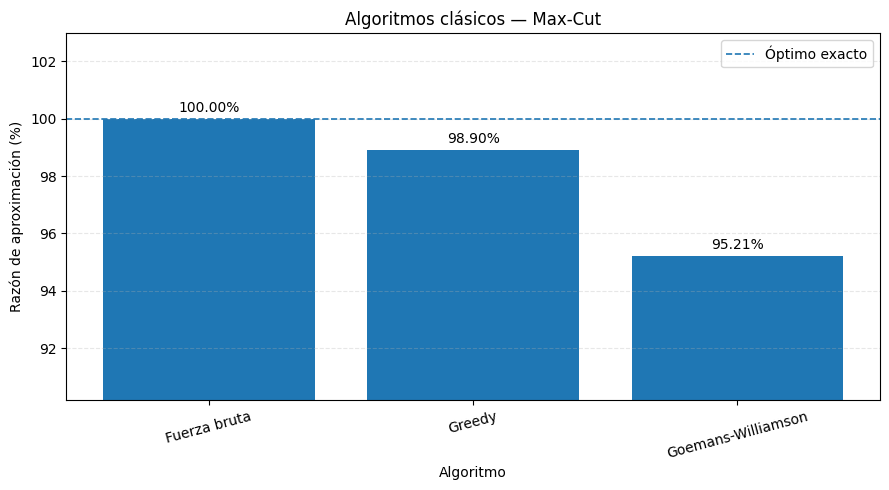

In [16]:
display(resultados["clasicos"]["tabla"])
if not resultados["clasicos"]["tabla"].empty:
    graficar_clasicos(resultados["clasicos"])


### 9.2 Tabla y gráfica — métodos cuánticos


,algoritmo,tipo_valor,valor_reportado,razon_aproximacion_pct,mejor_valor_observado,probabilidad_optimo_pct
0,QAOA local,valor esperado,231828.713022,78.226498,296355.736293,0.733333
1,QAOA + ZNE,valor extrapolado,232243.291537,78.366390,232243.291537,NaN
2,QAOA H2-Emulator,valor esperado,231332.351127,78.059009,296355.736293,2.200000


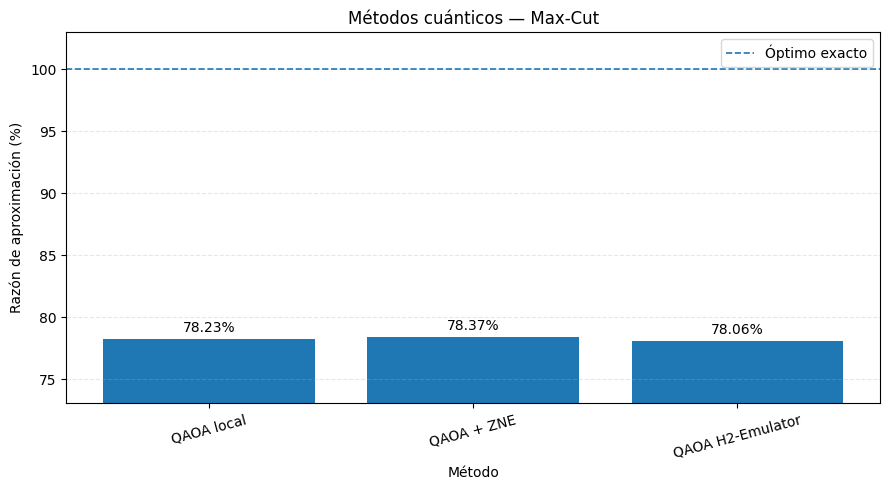

In [17]:
if resultados["cuanticos"] is not None:
    display(resultados["cuanticos"]["tabla"])
    graficar_cuanticos(resultados["cuanticos"])
else:
    print("QAOA no fue seleccionado; se ejecutó únicamente el bloque clásico.")


## 10. Uso rápido: solo los 3 clásicos

,algoritmo,tipo_valor,valor_reportado,razon_aproximacion_pct,mejor_valor_observado,probabilidad_optimo_pct
0,Fuerza bruta,óptimo exacto,296355.736293,100.000000,296355.736293,100.00
1,Greedy,corte obtenido,293084.925081,98.896323,293084.925081,NaN
2,Goemans-Williamson,promedio de redondeos,282151.162609,95.206918,296355.736293,39.43


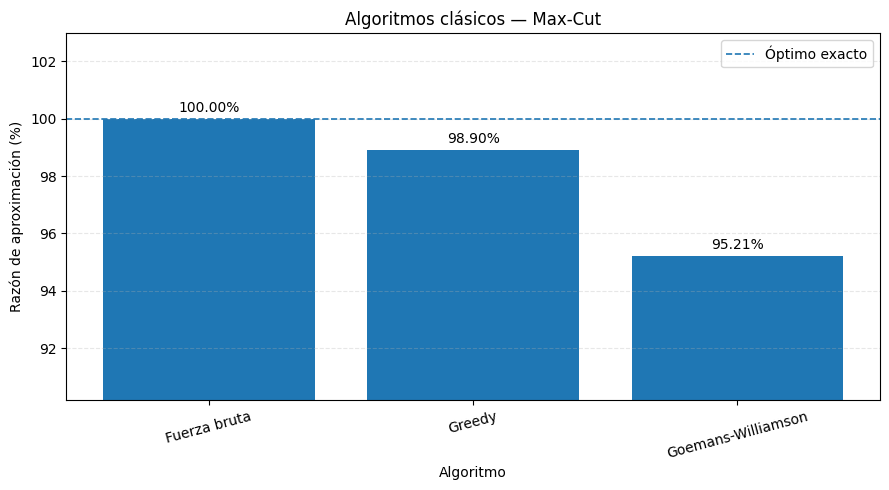

In [19]:
CONFIG["algoritmos"] = ("fuerza_bruta", "greedy", "goemans_williamson")
resultados = main(**CONFIG)
display(resultados["clasicos"]["tabla"])
graficar_clasicos(resultados["clasicos"])

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=05d689c6-8b29-48c8-baae-28673c227273' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>